# **Exploratory Data Analysis for Payment & Shipping**
####  subtitle 

## Table of Contents

- [0. EDA for ](#topic-0)
- [1. Import Libraries](#topic-1)
- [2. Import Data](#topic-2)
- [3. Analysis Section](#topic-3)
  - [3.1 ](#topic-3-1)
  - [3.2 ](#topic-3-2)
  - [3.3 ](#topic-3-3)
  - [3.4 ](#topic-3-4)
  - [3.5 ](#topic-3-5)
- [4. Conclusion & Insights Recap](#topic-4)
- [5. Recommendations based on Insights](#topic-5)


## **0. EDA for Payments & Shipping Summary** <a id="topic-0"></a>

***Will change this accordingly when finished***
- Product Category Landscape: Explore the distribution of product categories, identify dominant ones, and assess balance across the catalog.
- Product Weight & Volume Patterns: Analyze product size and weight trends to understand shipping and storage implications across categories.
- Seller Distribution & Activity: Examine how orders are distributed across sellers, highlighting the role of individual vs. large-scale sellers.
- Product-Seller Relationships: Understand how many sellers sell a product and how many products a seller lists to assess competition and specialization.
- Top Seller Performance: Identify the top-performing sellers based on both order volume and revenue to reveal market concentration.
- Operational & Strategic Insights: Extract meaningful patterns about inventory diversity, logistics needs, and seller dynamics to guide platform decisions.

## **1. Import Libraries** <a id="topic-1"></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## **2. Import Data** <a id="topic-2"></a>

In [3]:
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_timestamp", "order_estimated_delivery_date"]

orders = pd.read_csv('../data/processed/orders.csv')
orders[date_cols] = orders[date_cols].apply(pd.to_datetime, errors='coerce')  # Safely parse all, fallback if weird values

orders["delivery_time_gap"] = pd.to_timedelta(orders["delivery_time_gap"], errors='coerce')

order_items = pd.read_csv('../data/processed/order_items.csv')
customers = pd.read_csv('../data/processed/customers.csv')
payments = pd.read_csv('../data/processed/payments.csv')
products = pd.read_csv('../data/processed/products.csv')

## **3. Analysis Section** <a id="topic-3"></a>
***alter with corresponding text when done***
- Data Exploration: This section dives deep into products and seller performance, categorical trends in products, and seller dynamics using statistical & visualization methods.
- Visual-Driven: Data is visualized through a variety of plots — bar plots, histograms, KDEs, line graphs — to surface hidden patterns and outliers.
- Contextual Commentary: Every insight is paired with interpretation to understand its potential business or logistic impact.
- Subsection-Focused: The section is divided into specific focus areas like product category, dimensions, sellers order distribution analysis etc.
- Real-World Takeaways: Each analysis aims to bring forward operational or strategic implications, making the data actionable.

In [74]:
payments[(payments['payment_sequential'] > 1) & (payments['payment_installments'] == 1)]['payment_sequential'].nunique()

27

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,delivery_time_gap,delivery_time_gap_hrs,purchase_to_approval_hours,approval_to_delivery_hours,purchase_to_delivery_hours
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,13 days 01:40:08,313.668889,0.271944,99.094167,99.366111
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,20 days 01:08:38,481.143889,0.663611,312.517222,313.180833
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,8 days 22:30:10,214.502778,23.934444,225.237500,249.171944
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,22 days 03:56:09,531.935833,0.179722,217.809722,217.989444
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,12 days 04:37:11,292.619722,0.790833,337.855000,338.645833


In [6]:
products.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0,3648.0,0.134594
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0,4284.0,0.102708
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,0.537109
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0,9792.0,0.148080
4,1lycYGcsic2F,toys,300.0,17.0,4.0,12.0,816.0,0.367647


In [7]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_diff
0,Axfy13Hk4PIk,1,credit_card,1,259.14,49.02
1,v6px92oS8cLG,1,credit_card,8,382.39,-187.80
2,Ulpf9skrhjfm,1,credit_card,4,249.25,-167.47
3,bwJVWupf2keN,1,credit_card,2,27.79,267.43
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15,734.41


In [54]:
payments['payment_type'].value_counts()

payment_type
credit_card    62247
wallet         16308
voucher         4628
debit_card      1219
Name: count, dtype: int64

In [8]:
customers.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125,varzea paulista,SP
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119,jandira,SP
3,EOEsCQ6QlpIg,18212,uberlandia,MG
4,mVz5LO2Vd6cL,88868,ilhabela,SP


In [9]:
products.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0,3648.0,0.134594
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0,4284.0,0.102708
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,0.537109
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0,9792.0,0.148080
4,1lycYGcsic2F,toys,300.0,17.0,4.0,12.0,816.0,0.367647


---
#### **3.1 Payment Types Distribution** <a id="topic-3-1"></a>


In [76]:
payments['payment_type'].value_counts()

payment_type
credit_card    62247
wallet         16308
voucher         4628
debit_card      1219
Name: count, dtype: int64

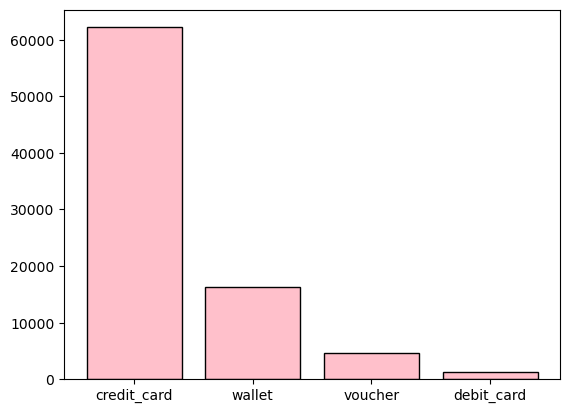

In [77]:
plt.bar(payments['payment_type'].value_counts().index, payments['payment_type'].value_counts(), color='pink', edgecolor='black')
plt.show()

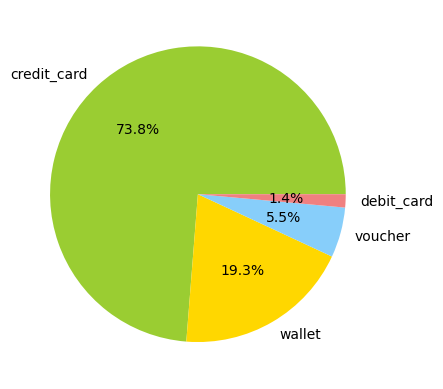

In [95]:
plt.pie(payments['payment_type'].value_counts(), labels=payments['payment_type'].value_counts().index, autopct='%1.1f%%', colors=['yellowgreen', 'gold', 'lightskyblue', 'lightcoral'])
plt.show()

**This implies that:**
- Credit card is the most preferred payment type, where about 3/4th of the payments are done through credit card. This preference shows a trust, popularity and availability of credit card facilities. This may also be due to the installment based payments too.
- Second most preferred option for payments is the Digital Wallet with 19.3% payments, indicating a good amount of adoption. This suggests that faster and easier payments are also being preferred, and this number may increase in the future with increasing adoption.
- Vouchers and debit cards get less than 7% of all payments, shows that, debit based and pre-paid purchases (for vouchers) is limited, possibly due to flexibility offered by digital wallets & credit-cards. Voucher usage being low suggests that, vouchers can be used for marketing and customer retention, but need to be more popularised.

#### **3.2 Installment Patterns** <a id="topic-3-2"></a>

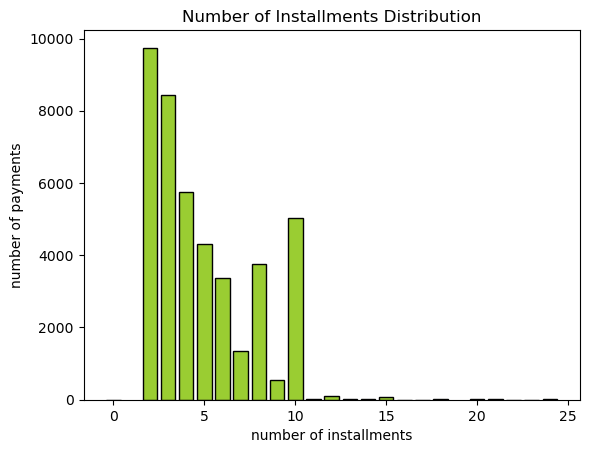

In [104]:
payment_installments_not_1 = payments['payment_installments'].value_counts().drop(1)
plt.bar(payment_installments_not_1.index, payment_installments_not_1, color='yellowgreen', edgecolor='black')
plt.xlabel('number of installments')
plt.ylabel('number of payments')
plt.title('Number of Installments Distribution')
plt.show()

In [124]:
payments['payment_installments'].value_counts().sort_values()

payment_installments
22        1
23        1
0         3
17        6
16        6
14        9
21        9
13       15
20       16
11       18
24       23
18       26
15       68
12      116
9       534
7      1338
6      3368
8      3753
5      4304
10     5024
4      5741
3      8442
2      9745
1     41836
Name: count, dtype: int64

In [125]:
payments['payment_installments'].value_counts().drop(1).sum()

42566

In [120]:
payments['payment_installments'].value_counts().drop([1,2,3,4,5,6,10,12,15,20,24]).sum()

5719

In [115]:
payments[payments['payment_type'] == 'credit_card']['payment_installments'].describe()

count    62247.000000
mean         3.668096
std          2.956340
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         24.000000
Name: payment_installments, dtype: float64

In [114]:
payments[payments['payment_type'] != 'credit_card']['payment_installments'].describe()

count    22155.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: payment_installments, dtype: float64

**This implies that:**
- The number of payments done with installments is 42566 (50.4 % of total payments), suggesting that about half of the payments are done using installments. Out of which 2 installment payments are 9745 (about 22.3 % of installment payments & 12% of total payments).
- The trend in the number of installments with number of payments/transactions, goes down normally from 2 installments onwards steadily upto 5-6 installments.
- Then number of installments like 8, 10, 12, 15, 20 and 24 hike, being favorable and simple options to choose, as 10, 15 and 20 are multiple of 5s simple to choose, and 12 & 24 allows an installment every month of one or two years, another favorable option.
- Odd numbers in number of installments appear rarely appear in payments, where just 5719 out of 84402 (approx. 6.8%) have these odd number of installments.
- Also, the number of installments in all payments other than credit card payments is one (1), this means that payment in installments option should only be available with credit cards.

#### **3.3 Installments Vs. Payment Values** <a id="topic-3-3"></a>

- trying correlation + regression line to get correlation.
- Mean price vs installment type bar plot.
- and something

#### **3.4 title** <a id="topic-3-4"></a>

#### **3.5 title** <a id="topic-3-5"></a>

---
## **4. Conclusion & Insights Recap** <a id="topic-4"></a>

---
## **5. Recommendations based on Insights** <a id="topic-5"></a>
